<a href="https://colab.research.google.com/github/Sergei-N-Fedorov/Data_Analysis/blob/main/MLPR26_exercise_Fedorov_Sergei.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Leaf Classification Exercise**
#Machine Learning and Pattern Recognition (TKO_3120)

Student's name: **Sergei Fedorov**<br>
Student number: **2511405**<br>
email: sefedo@utu.fi<br>

# Introduction

The purpose of the task is to implement classification of three types of leaves with three types of supervised machine learning methods applied to a generated feature set for the given data.


## Data

The initial dataset consists of leaf images from three plant species:

* _Basil_  (class label `0` in the following code),

* _Chinar_  (class label `1`),

* _Lemon_  (class label `2`).

The data is originated from Kaggle, where there are examples of healthy and deseased leaves of numerous plant species. The sample provided represents a set of color images with reduced resolution, namely
these are RGB images of size $180 \times 120$.
Each of three classes contains 60–62 images of healthy leaves except for the Lemon class which also includes 10 examples of deseased leaves.
Ignoring the presence of deseased leaves in one class, one can conclude that the data is balanced.


## Feature generation

To apply machine learning methods to the data, we generate a set of 13 features from the images. For that, we use

* the original color images to get means and variances of their RGB channels;

* their grayscale variants (256 levels) to get template matching metrics, when templates are taken from one image of each class;

* the grayscale images quantized to 8 levels to get the levels' four co-occurence metrics.

The generated features are then analyzed in terms of

* possible pairwise correlation (pairplots),

* their individual capability to distinguish the classes (classwise histograms),

* their common class separation capability through PCA.


## ML methods

Three types of ML models are used for the classification task:

* Ridge classifier (linear model),

* Random Forest classifier (decision tree ensemble model),

* Multi-layer Perceptron (neural network) with one hidden layer.

For each architecture, the best hyperparameter values are determined through Grid Search Cross-Validation technique. Performance evaluation is made by _accuracy_ score, which is appropriate since the dataset is balanced (overwise accuracy as an evaluation measure may be misleading). The three best models (those with the best hyperparameters) are assessed on a test dataset to get their final evaluation scores (accuracy again).

After the evaluation of the individual best models, the three learning methods are assessed with help of Nested Cross-Validation. This yields more reliable evaluation since we avoid possible lucky cases of a specific model performance on a specific dataset.

# Data Preparation

In this section the initial data is prepared for the followin feature extraction step.

In [14]:
import os
import cv2
import numpy as np
import pandas as pd

# plots
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn
### normalization
from sklearn.preprocessing import StandardScaler
### feature selection
from sklearn.decomposition import PCA
### cross-validation
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
### classification models
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
### evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
###
from sklearn.pipeline import Pipeline

# scikit-image
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.feature import graycomatrix, graycoprops

In [15]:
path = 'data'     # location of 3 directories with leaf images
classes = ['Basil', 'Chinar', 'Lemon']  # => 0 = Basil, 1 = Chinar, 2 = Lemon

In the next piece of code, the image data are read and written in a list of arrays (`X`). The elements of the list are transformed into grayscale images (`X_gray`) for template matching and then into 8-level grayscale images (`X_gray_8`) to reduce computational expenses when calculating Gray-Level Co-occurance Matrices. The labels of the classes are determined by that directory from which each image is taken.

In [16]:
# Read data and transform it

X = []        # initial (color) images
X_gray = []   # grayscale images (for template matching)
X_gray_8 = [] # 8-level grayscale images (for GLCM)
y = []        # labels

for c in range(3):
  dir = path + '/' + classes[c]
  files = os.listdir(dir)
  for f in files:
    img = imread(dir + '/' + f) # load image as numpy array
    X.append(img)               # datapoint
    im_gray = rgb2gray(img)     # convert to grayscale
    im_gray = (im_gray * 255).astype(np.uint8) # return to 256 levels
    X_gray.append(im_gray)      # datapoint in grayscale
    # im_gr_8 = (im_gray * 8).astype(int)
    im_gr_8 = (im_gray // 32).astype(np.uint8) # quantized to 8 levels
    # im_gr_8 = np.clip(im_gr_8, 0, 7)
    X_gray_8.append(im_gr_8)    # quantized grayscale variant
    y.append(c)                 # label of its class

# Convert lists to numpy arrays
X = np.array(X)
X_gray = np.array(X_gray)
X_gray_8 = np.array(X_gray_8)
y = np.array(y)

Now, we can look at what we just got: here is an example of a chinar leaf in 3 modes.

(184, 120, 180, 3)

(184, 120, 180)

(184, 120, 180)

(184,)

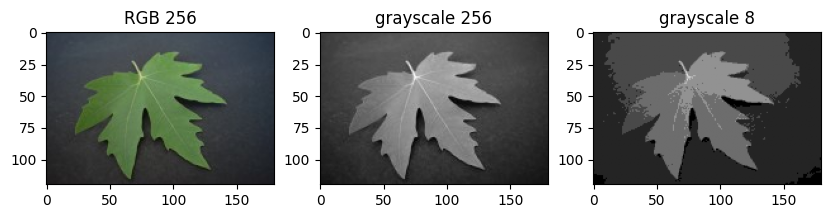

In [17]:
display(X.shape)
display(X_gray.shape)
display(X_gray_8.shape)
display(y.shape)

fig, ax = plt.subplots(1, 3)
fig.set_size_inches(10, 5)
ax[0].imshow(X[100])
ax[0].set_title('RGB 256')
ax[1].imshow(X_gray[100], cmap = 'gray')
ax[1].set_title('grayscale 256')
ax[2].imshow(X_gray_8[100], cmap = 'gray', vmin=0, vmax=7)
ax[2].set_title('grayscale 8')
plt.show()

# Feature Extraction

Now that the data is prepared, we can generate (exract) features that ML model can be later trained on.

These are obtained by

* 6 first-order texture measures for color images:

  * **mean** value of **r**ed channel (`R_mean`),

  * **mean** value of **g**reen channel (`G_mean`),

  * **mean** value of **b**lue channel (`B_mean`),

  * **var**iance value of **r**ed channel (`R_var`),

  * **var**iance value of **g**reen channel (`G_var`),

  * **var**iance value of **b**lue channel (`B_var`);

* 4 second-order texture measures from Gray-Level Co-Occurrence Matrix (GLCM) for 8-level grayscale images:

  * correlation of GL**CM** for distance **1** in (both) **h**orizontal directions, i.e., for closest neighbours on the left and on the right (`CM_1h`),

  * correlation of GL**CM** for distance **1** in (both) **v**ertical directions, i.e., for closest upper and lower neighbours (`CM_1v`),

  * correlation of GL**CM** for distance **2** in (both) **h**orizontal directions, i.e., for the neighbours two steps on the left and on the right (`CM_2h`),

  * correlation of GL**CM** for distance **2** in (both) **v**ertical directions, i.e., for neighbours two steps up and down (`CM_2v`);

* 3 template matching measures for 256-level grayscale images:

  * degree of **m**atch with a **basil** leaf **t**emplate (`TM_basil'),

  * degree of **m**atch with a **chinar** leaf **t**emplate (`TM_chinar'),

  * degree of **m**atch with a **lemon** leaf **t**emplate (`TM_lemon'),

In total, 13 features will be generated.

Below, there is more detailed description for each of three feature groups.

## First-order texture measures: mean and variance of color channels

Each image gets 6 features: mean and variance for each of 3 RGB color channel matrices.

These measures reflect the overall average color intensities and their range. Besides the color and brightness of a leaf, the measures perhaps also capture its size because the overall brightness of an image depends on the area the brighter leaf cover on the dark background.

In [18]:
# Mean and variance of each image's color channels
means = np.zeros((X.shape[0], 3))
vars = np.zeros((X.shape[0], 3))

for i in range(len(X)):
  for ch in range(3):
    m = np.mean(X[i, :, :, ch], axis = (0, 1), keepdims=True)  # 2D array of size 1 × 1
                          # this form is needed to reuse mean in variance calculations
    means[i, ch] = m.item()
    vars[i, ch] = np.var(X[i, :, :, ch], axis = (0, 1), mean = m)

## Second-order texture measures: GLCM correlation

Gray-Level Co-occurence matrix (GLCM) of an image describes its texture by considering the spatial relationships of pixels. It counts how often two neighbouring (in a sense) pixels in the image have a certain pair of gray-level values. Thus, GLCM is a square matrix of size being the number of gray levels ($8 \times 8$ in our case). $GLCM_{i,j}$ is the number of neighbouring pixel pairs such that the first one has gray level $i$ and the second one has gray level $j$ (or in the other order in the symmetric measure case).

The meaning of "neighbouring" is determined by two parameters:

* the distance between two pixels (integer value),

* the direction, or angle, in which we look for the neighbour (left, right, up, down, right-down, etc. or, in symmetric case, horizontal, vertical, diagonal).

If the image texture is smooth and neighbouring pixels have similar levels, the GLCM has large values on its diagonal and around it. Speckled or noisy texture may lead to a GLCM with larger values further from the diagonal.

To get one value per image from its GLCM as a concise representation of texture property, we use the _correlation_ feature that measures how strongly pixel values are related in the image:

$$\sum_{i,j=0}^{l-1} P_{i,j}\frac{(i-\mu_i) \
(j-\mu_j)}{\sqrt{(\sigma_i^2)(\sigma_j^2)}},$$

where $P_{i,j}$ are normalized elements of the GLCM (probabilities of level pairs), $l$ is the number of layers, $\mu_i, \sigma_i^2$ are mean and variance of $i$th row, $\mu_j, \sigma_j^2$ are mean and variance of $j$th column.

 High correlation values indicate a _predictable_ relationship between pixel intensities in the image (e.g., when a pixel is bright, we can say its neighbouring pixel is likely to be bright too).
A structured and repetitive pattern in the image would yield high correlation feature.


In [19]:
dist = [1, 2]         # distances: 1 or 2
angl = [0, np.pi/2]   # directions (angles): 0° (horizontal) or 90° (vertical)
glcm_crl = np.zeros((len(X_gray_8), len(dist) * len(angl))) # to collect values

for i in range(len(X_gray_8)):
  glcm = graycomatrix(X_gray_8[i],        # 4 GLCMs for
                      distances = dist, # distances d = 1 / d = 2
                      angles = angl,    # horizontal / vertical directions
                      levels = 8,
                      symmetric = True, # in both directions (←→ / ↑↓)
                      normed = True     # matrices are normed for the following
                     )
  glcm_crl[i] = graycoprops(glcm, 'correlation').flatten()  # correlation of GLCM
        # order of features (d, a): 1-horiz, 1-vert, 2-horiz, 2-vert

## Template matching

Here, we try to get features measuring how similar (by form/shape) a leaf in the image is to some reference leaves of 3 classes.

One (first) grayscale image of each class is selected for the template and then the leaf itself is cropped from it. It is done (against the possibility to use a full image as a template) because not all the images seem to be well centered.
Still, the `matchTemplate` method cannot handle the rotated or scaled leaves which is often the case in this dataset.

It should be noted that perhaps some smarter way of choosing the representative image for each class is needed. But I didn't find any clearly better approach.

Template matching builds a matrix of values reflecting the degree of similarity to a template for each location/position. Again, we need a single value for each image-template pair.

_Normalized cross-correlation coefficient_ is used to measure how closely each image part matches each template.
Then, the single _maximum response_ value is used as a feature, representing how similar the leaf shape in the image is to the specific class template.

The usefulness of such a feature seems to be self-evident because it is exactly how a human would tell one leaf from another — by their form, first of all. The chinar leaves have very characteristic form. Hence (if we could implement template matching with transformations) we would probably be able to classify chinar leaves without mistakes at all just comparing them against an example form.

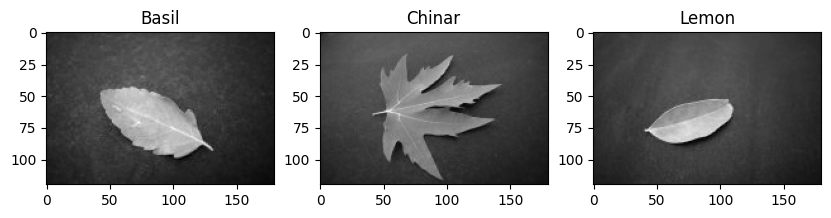

In [20]:
# Read again the first images of each class to provide reproducibility
tmpl_0 = imread('data/Basil/0008_0011.JPG')
tmpl_0 = (rgb2gray(tmpl_0) * 255).astype(np.uint8)
tmpl_1 = imread('data/Chinar/0011_0011.JPG')
tmpl_1 = (rgb2gray(tmpl_1) * 255).astype(np.uint8)
tmpl_2 = imread('data/Lemon/0010_0108.JPG')
tmpl_2 = (rgb2gray(tmpl_2) * 255).astype(np.uint8)

templates = {'Basil' : tmpl_0,    # template images
             'Chinar' : tmpl_1,
             'Lemon' : tmpl_2}

fig, ax = plt.subplots(1, 3)
fig.set_size_inches(10, 5)
for i in range(3):
  ax[i].imshow(templates[classes[i]], cmap='gray')
  ax[i].set_title(classes[i])
plt.show()

These are the images taken for templates.
(It seems that the files are read in different order from time to time. Thus, it was more reliable to read the template candidates again by file names.)

Next, we crop the leaves, dropping a large part of background.

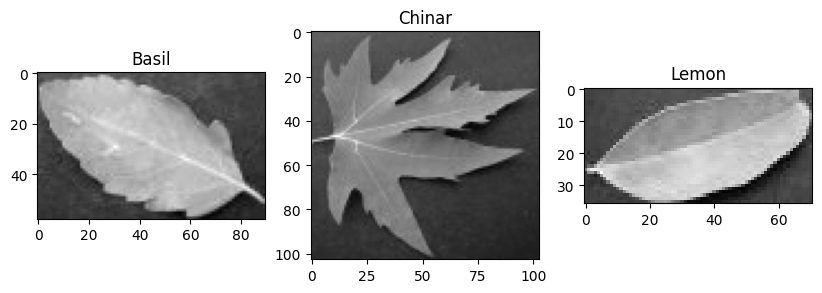

In [21]:
# Crop the leaves for the templates

templates['Basil'] = templates['Basil'][42:100, 42:132]
templates['Chinar'] = templates['Chinar'][15:118, 42:145]
templates['Lemon'] = templates['Lemon'][52:88, 40:111]

fig, ax = plt.subplots(1, 3)
fig.set_size_inches(10, 5)
for i in range(3):
  ax[i].imshow(templates[classes[i]], cmap='gray')
  ax[i].set_title(classes[i])
plt.show()

Now, we can extract the template matching feature values with help of the `cv2.matchTemplate` function.

In [22]:
# Template matching

template_matching_scores = np.zeros((len(X), 3))

for i in range(len(X)):
  for c in range(len(classes)):
    # normalized cross-correlation for the template of class c and image i
    res = cv2.matchTemplate(X_gray[i], templates[classes[c]], cv2.TM_CCOEFF_NORMED)
    template_matching_scores[i, c] = np.max(res) # max. response value

# Feature analysis

In this section, we investigate the generated feature set

* by comparing them pairwise to see possible correlation/dependancy between them,

* by comparing their distribution between classes to check their classification strength,

* by assessing how well they (their combinations) can classify the datapoints.


Before that, let's put all the feature values together into a single structure (an array and a dataframe) for ease of use.
We also will need a scaled version of these data to implement PCA.

In [23]:
features = np.concatenate((means, vars, glcm_crl, template_matching_scores), axis = 1)  # array

feature_names = ['R_mean', 'G_mean', 'B_mean', 'R_var', 'G_var', 'B_var', 'CM_1h', 'CM_1v', 'CM_2h', 'CM_2v', 'TM_basil', 'TM_chinar', 'TM_lemon']
feat_df = pd.DataFrame(features)       # dataframe
feat_df.columns = feature_names

print(f"The dimensions of the data: {feat_df.shape}\n")
feat_df.head().style.format('{:.4f}')

The dimensions of the data: (184, 13)



,R_mean,G_mean,B_mean,R_var,G_var,B_var,CM_1h,CM_1v,CM_2h,CM_2v,TM_basil,TM_chinar,TM_lemon
0,46.5481,51.5409,39.6020,482.8844,995.2747,179.1196,0.9524,0.9401,0.9141,0.8897,0.3493,0.5186,0.6742
1,41.1815,45.9446,37.7360,290.8919,718.2430,107.4723,0.9560,0.9371,0.9265,0.8929,0.5055,0.5158,0.5408
2,44.7051,52.0452,38.9040,433.3207,1070.3676,174.5074,0.9662,0.9506,0.9420,0.9082,0.4594,0.5421,0.5142
3,38.8888,40.1426,39.1564,249.6157,534.0734,110.1817,0.9461,0.9294,0.9108,0.8791,0.5323,0.5442,0.6738
4,47.9295,53.0192,41.5512,577.4599,1146.1196,193.5893,0.9589,0.9497,0.9265,0.9104,0.4795,0.5119,0.5349


In [24]:
# Standardization (z-score normalization) of the feature values
# for PCA

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)  # array
feat_df_scaled = pd.DataFrame(features_scaled)    # dataframe
feat_df_scaled.columns = feature_names
feat_df_scaled['class'] = y

## Feature pairplots

We can look at how each pair of the features behave together (correlate) with help of pairwise scatterplots.

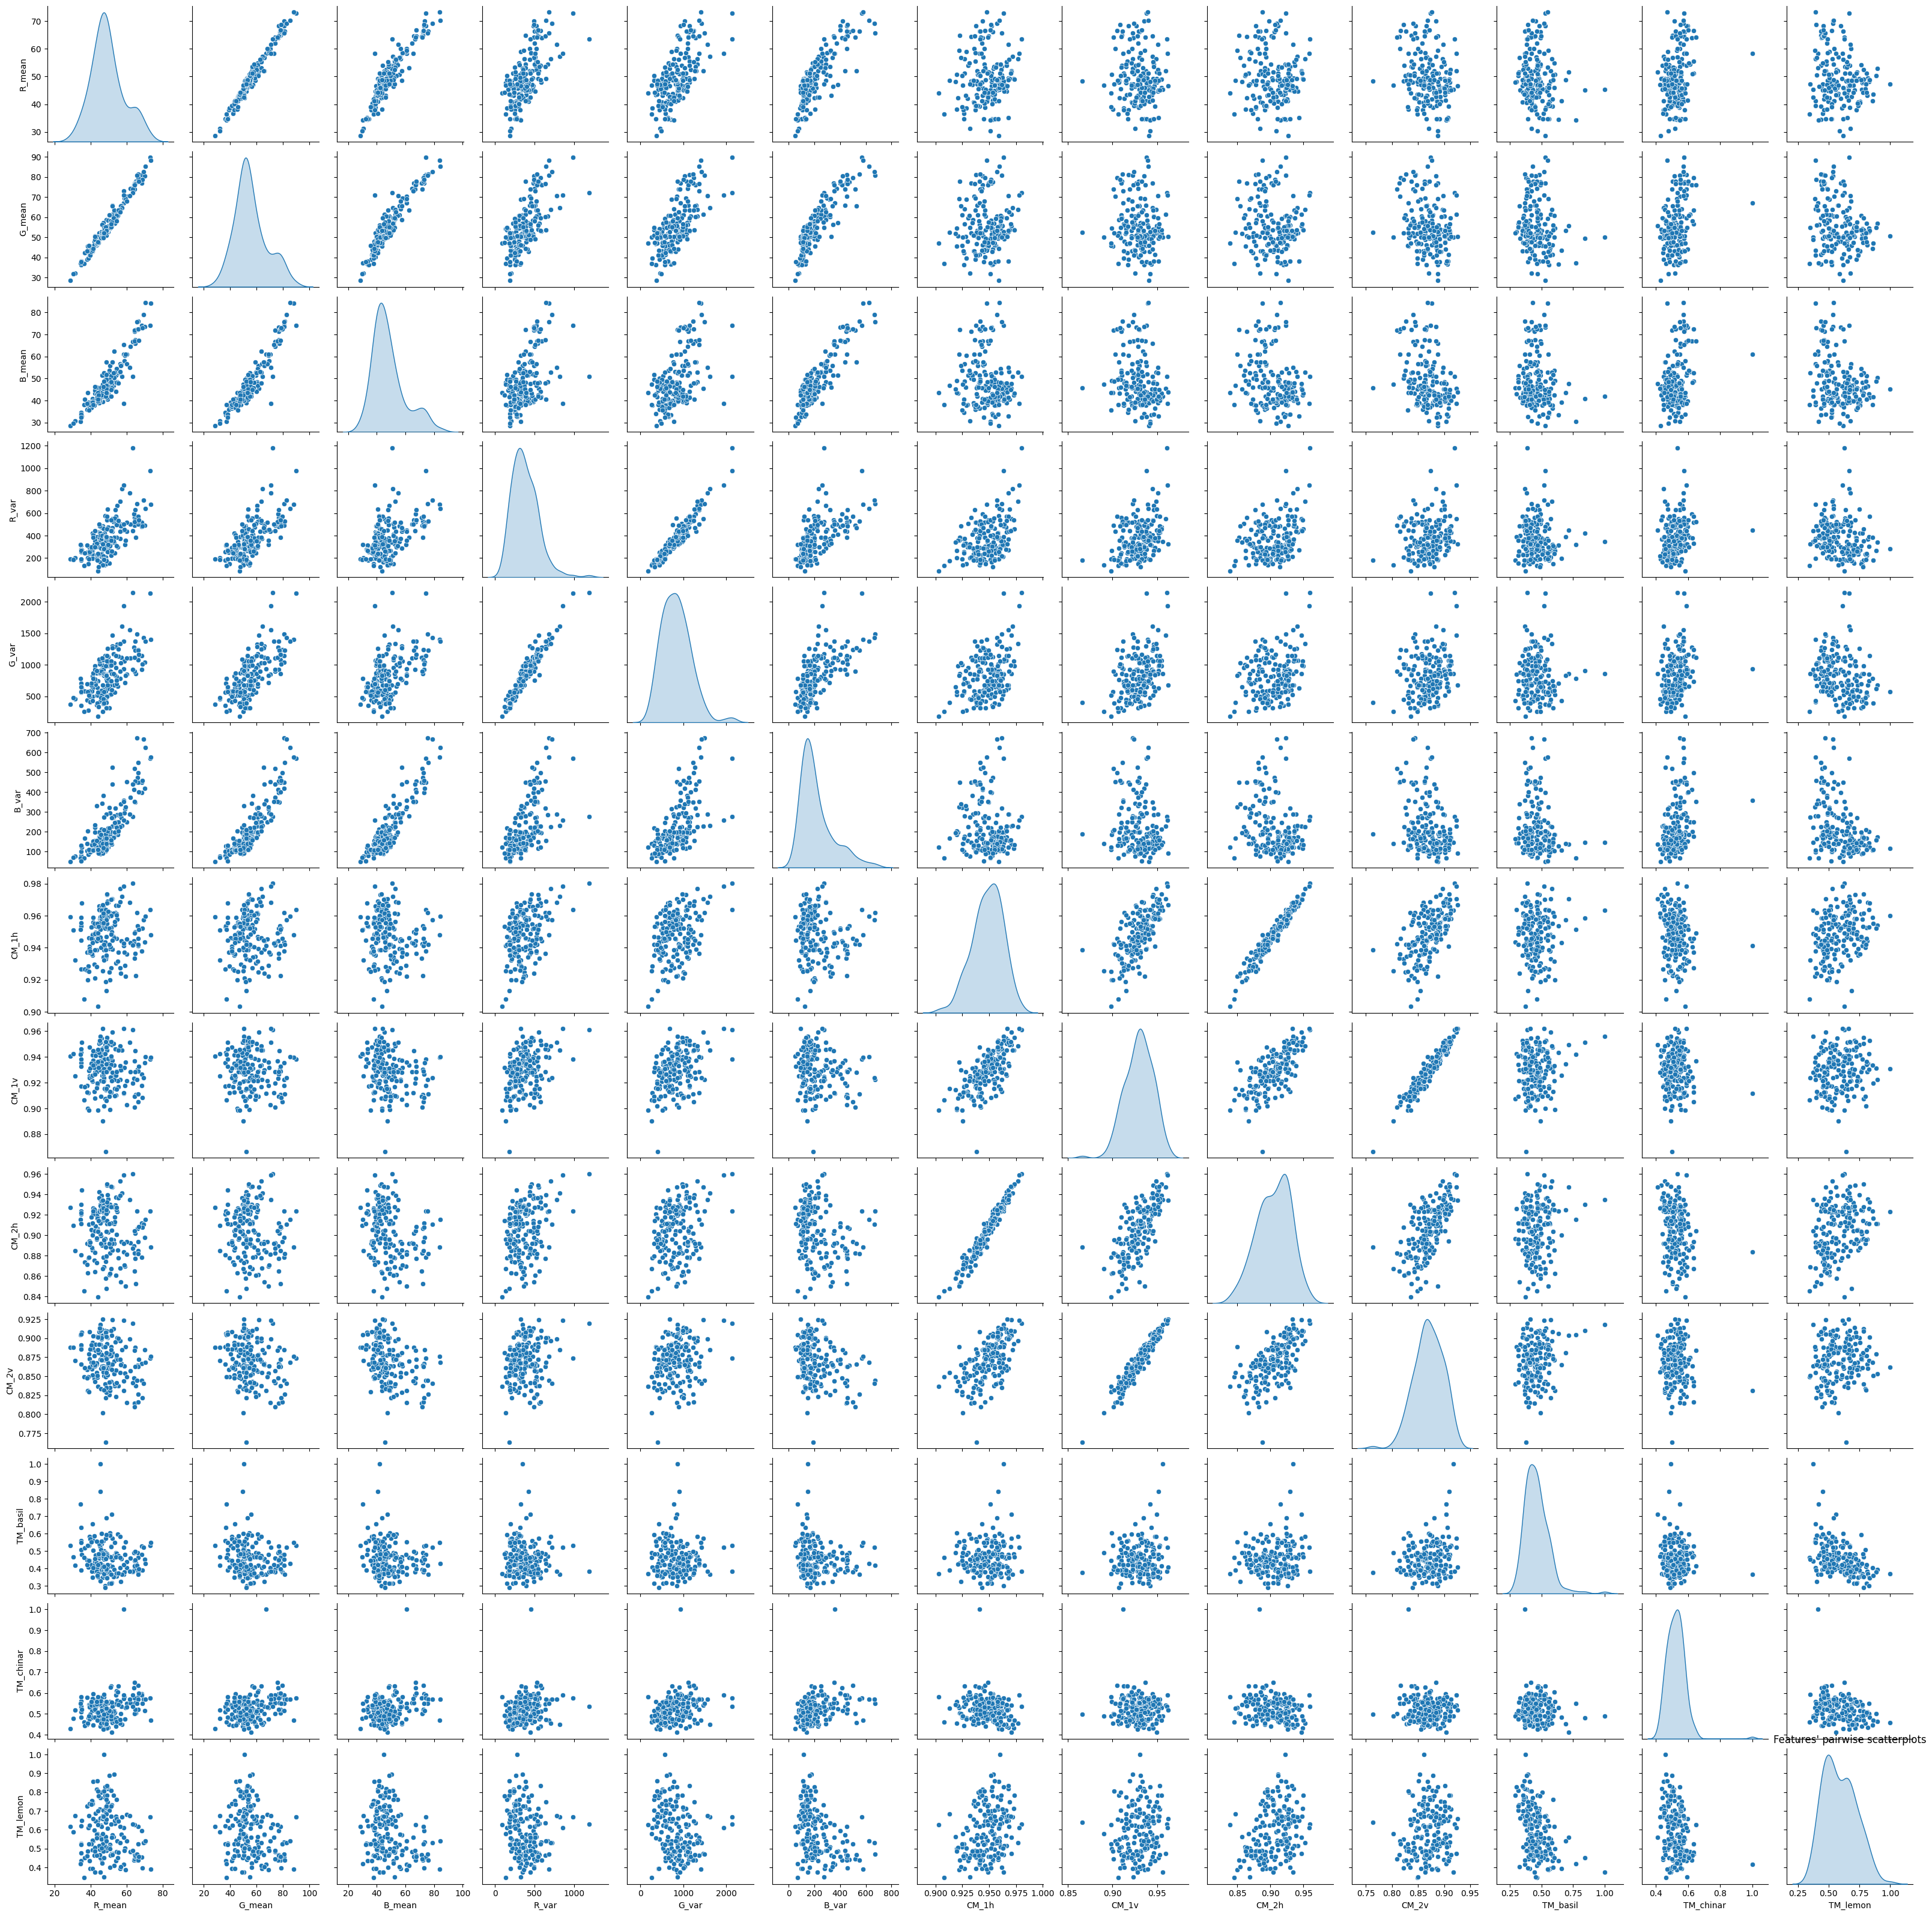

In [25]:
# Pairplot of the features
sns.pairplot(feat_df, diag_kind='kde')
plt.title("Features' pairwise scatterplots")
plt.show()

We can see that the following feature pairs show approximately linear dependence:

* means of red and green channels (`R_mean` ~ `G_mean`),

* (blue channel mean `B_mean` also correlates with them but a bit less),

* variances of red and green channels (`R_var` ~ `G_var`),

* CLCM correlation for horizontal distances 1 and 2 (`CM_1h` ~ `CM_2h'),

* CLCM correlation for vertical distances 1 and 2 (`CM_1v` ~ `CM_2v').

We can conclude that the difference in distances doesn't contribute much in classification and the features with one of the distance values can be dropped.

Also, one of the color channels is redundunt. We can drop, for example, the features for the green channel.

## Class-wise feature histograms

To estimate the capability of each single feature to distinguish the classes, we can look at the features' histograms: if a feature has essentially different histograms (i.e., not much overlapping) for different classes, this feature can be considered as good for classification.

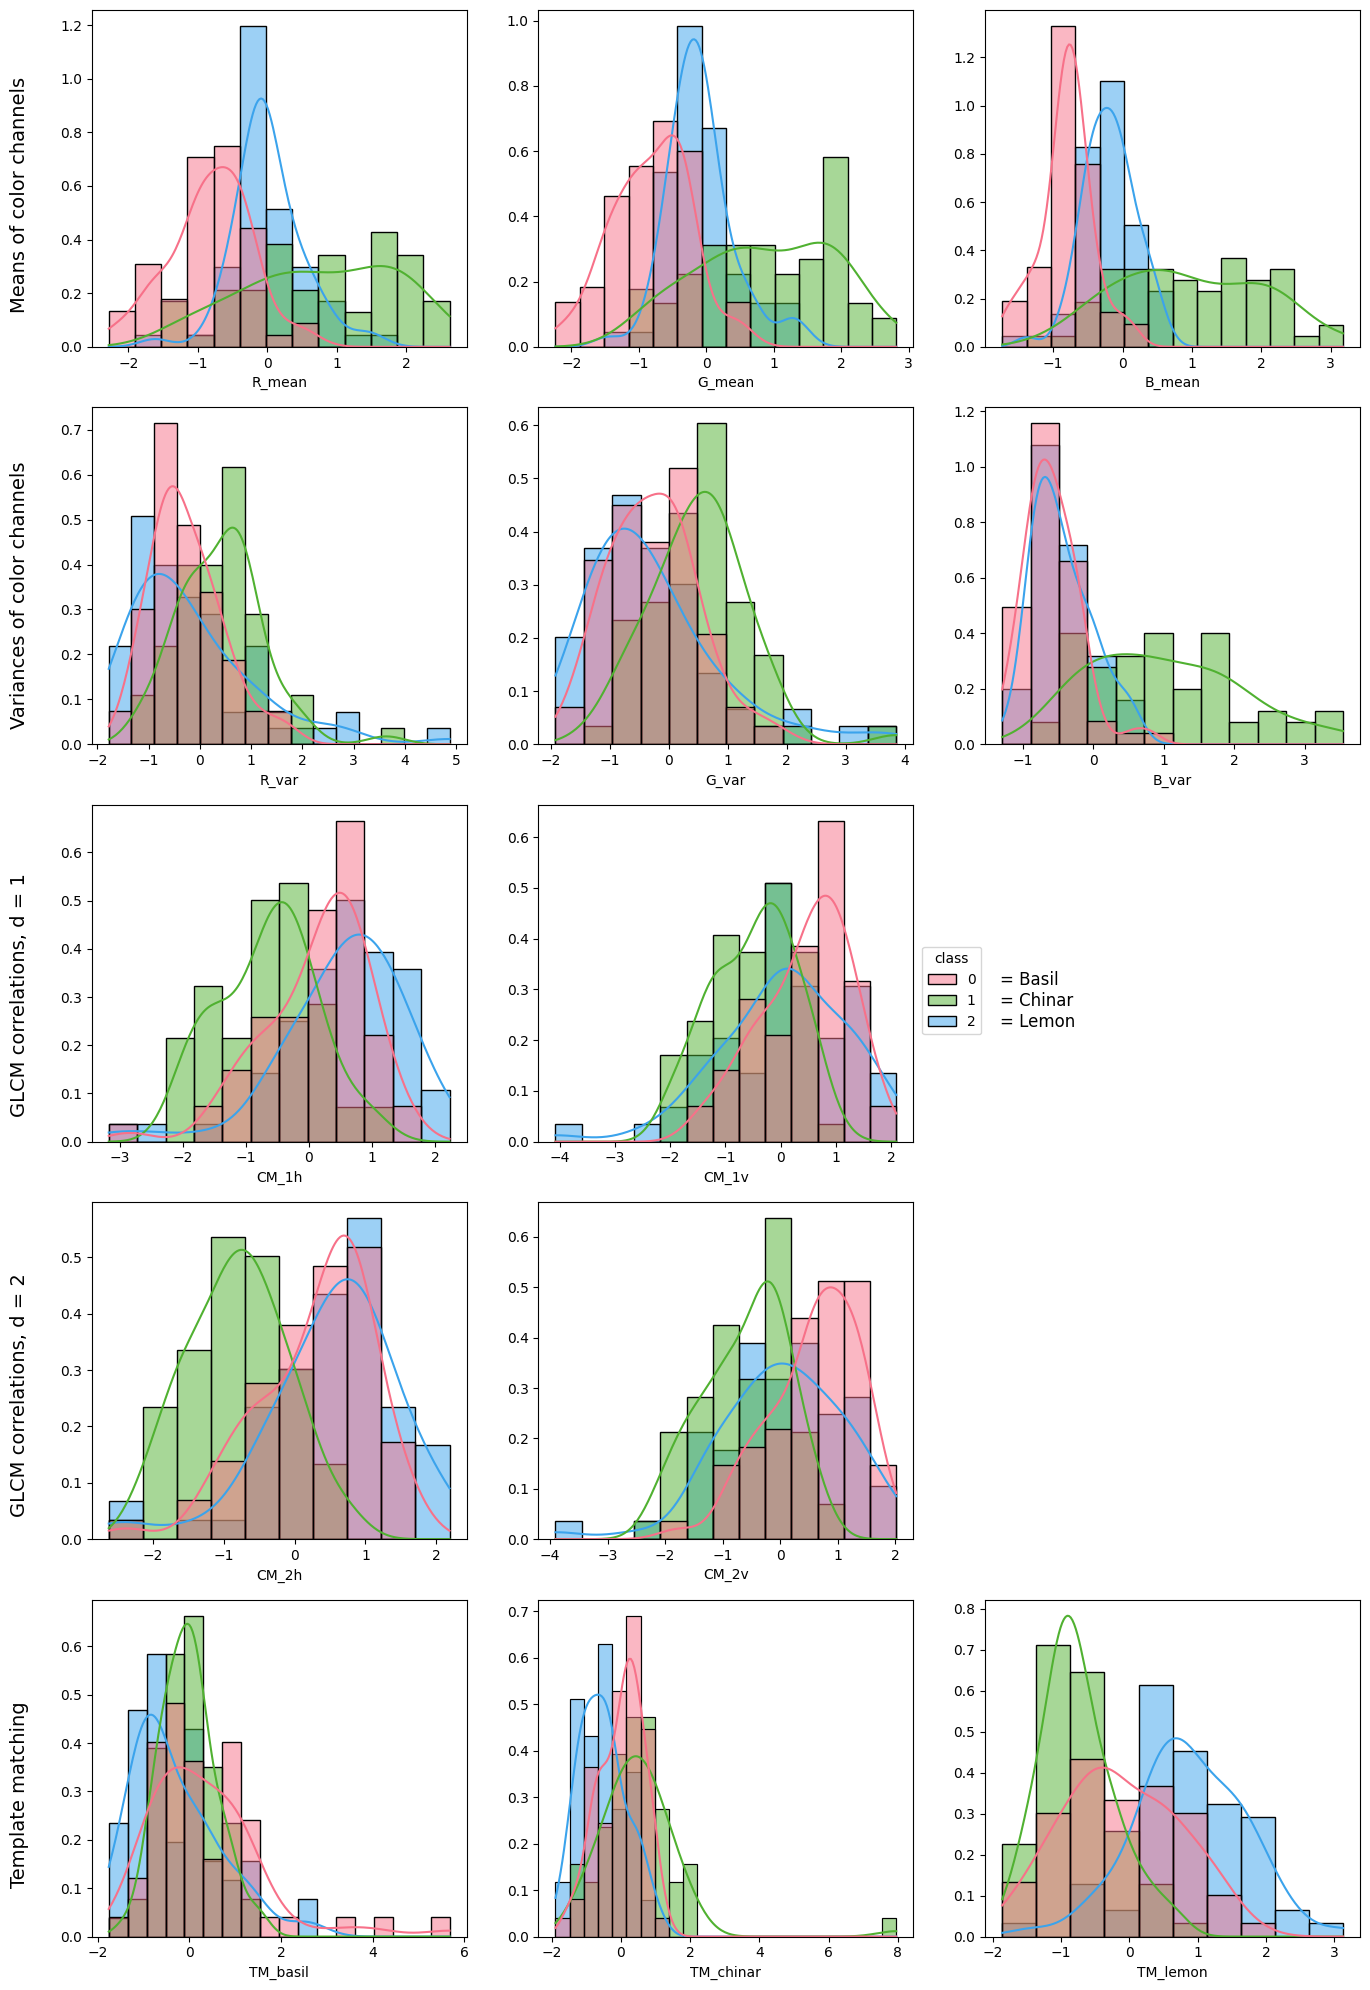

In [26]:
# Histograms for each feature and each class

fig, ax = plt.subplots(5, 3, figsize=(14, 20))
palette = sns.color_palette("husl", 3) # 'Set2', 'tab10',

common_kwargs = dict(       # common settings for subplots
    hue = 'class',
    kde = True,
    stat = 'density',
    palette = palette,
    common_norm = False,
    legend = False
)

for j in range(3):                    # means of color channels
  sns.histplot(feat_df_scaled,
               x = feature_names[j],
               **common_kwargs,
               ax = ax[0, j]
              )
  ax[0, j].set_ylabel("")
fig.text(0.025, 0.9, "Means of color channels", rotation=90, va='center', fontsize=14)
for j in range(3):                    # variances of color channels
  sns.histplot(feat_df_scaled,
               x = feature_names[j + 3],
               **common_kwargs,
               ax = ax[1, j]
              )
  ax[1, j].set_ylabel("")
fig.text(0.025, 0.7, "Variances of color channels", rotation=90, va='center', fontsize=14)
#for j in range(2):                   # GLCM correlations for distance 1
sns.histplot(feat_df_scaled,
               x = feature_names[0 + 6],
               **common_kwargs,
               ax = ax[2, 0]
              )
ax[2, 0].set_ylabel("")
sns.histplot(feat_df_scaled,
               x = feature_names[1 + 6],
               hue = 'class',
               kde = True,
               stat = 'density',
               palette = palette,
               common_norm = False,
               legend = True,        # use its legend
               ax = ax[2, 1]
              )
leg = ax[2,1].get_legend()
leg.set_bbox_to_anchor((1.2, 0.6))   # move the local legend
#leg._loc = 'center left'
ax[2, 1].set_ylabel("")
ax[2, 2].set_visible(False)
fig.text(0.025, 0.5, "GLCM correlations, d = 1", rotation=90, va='center', fontsize=14)
for j in range(2):                    # GLCM correlations for distance 2
  sns.histplot(feat_df_scaled,
               x = feature_names[j + 8],
               **common_kwargs,
               ax = ax[3, j]
              )
  ax[3, j].set_ylabel("")
ax[3, 2].set_visible(False)
fig.text(0.025, 0.3, "GLCM correlations, d = 2", rotation=90, va = 'center', fontsize = 14)
for j in range(3):                    # class template matching
  sns.histplot(feat_df_scaled,
               x = feature_names[j + 10],
               **common_kwargs,
               ax = ax[4, j]
              )
  ax[4, j].set_ylabel("")
fig.text(0.025, 0.1, "Template matching", rotation=90, va = 'center', fontsize = 14)
fig.text(0.732, 0.497, "= Basil\n= Chinar\n= Lemon", va = 'center', fontsize = 12)

plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.show()

From the plots above, we see that no of individual feature can separate the classes sufficiently well.
The ranges with the most frequent values for each class are overlapping significantly.

The exception would be the color channel means, especially `B_mean`,and also `B_var`, which can distinguish the chinar class with good likelihood.

Another relatively good feature is GLCM correlation for horizontal distance 2 (`CM_2h`) which is also able to distinguish the chinar class quite (well when its value is negative after scaling).

## Principal component analysis

The PCA technique for dimensionality reduction can be used to find two (new) features that make possible to visualize the dataset on the plane. This can help in determining if the classes are well separable.

In [27]:
# PCA
pca = PCA(n_components = 2)
features_pca = pca.fit_transform(feat_df_scaled)
feat_df_pca = pd.DataFrame(features_pca)
feat_df_pca.columns = ['PC1', 'PC2']
feat_df_pca['class'] = y

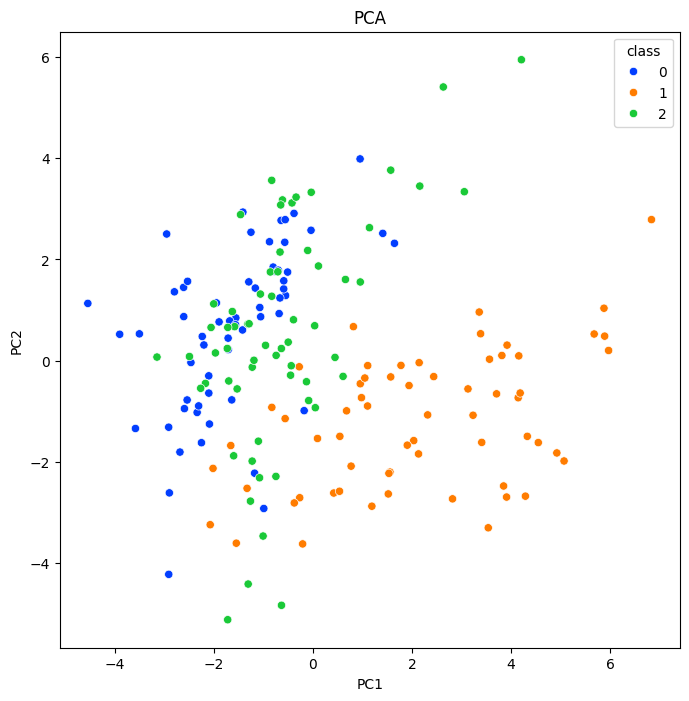

In [28]:
# PCA visualization
plt.figure(figsize = (8, 8))
sns.scatterplot(data = feat_df_pca, x = 'PC1', y = 'PC2', hue = 'class', palette = 'bright')
plt.title('PCA')
plt.show()

Can you see clusters?

What does PCA suggest about classification performance?

The plot shows that the chinar class is indeed very good separable from other classes. One can easily draw a simple boundary so that the number of misclassified points of the chinar class would be small.

However, the basil and lemon classes are strongly mixed in the plot which means it might be really hard to separate them.

# Building classifiers through cross validation

We will train classifiers of three different architecture types: Ridge classifier, Random Forest, and Multi-layer Perceptron.

For each of three ML methods, we build a concrete model by hyperparameter selection using Stratified $K$-Fold Cross Validation ($K = 5$) with GridSearchCV.

That means a model is trained on each of $K$ dataset splits with each combination of suggested hyperparameters. Then, the model with the best performance (measured with accuracy score in our case) is selected.

We apply this hyperparameter selection process on a training part `X_train` of the dataset (80 % of all given data), so that the resulting model, which is trained by `GridSearchCV` on whole `X_train`, can be evaluated on unseen data (`X_test`). This is in addition to accuracy score calculated by `GridSearchCV`.

(Although evaluation on `X_test` yields unrealistic values of accuracy (much higher than those of `GridSearchCV`) this is the only way to get confusion matrix and classification report I am aware of.)

First, we prepare a test set, and the remaining part of the dataset will be used for `GridSearchCV` so that later we can evaluate the resulting models.

Training and test sets are scaled after each splitting inside `GridSearchCV` (by using pipelines _scaler-classifier_) to prevent even minor data leakage between training and test setups: the scaler is fitted on the training set and applied to both sets.

### Ridge Classifier

Linear model builded on a base of linear regressor.  It uses an error function with a regularization term for prevent weight grow. The term's coefficient `alpha` is the model hyperparameter which we select from the set [0.001, 0.01, 0.1, 1.0].

In [29]:
# Split data to evaluate the best model after its selection through GridSearch
X_train, X_test, y_train, y_test = train_test_split(features, y,
                                                    test_size = 0.2,
                                                    stratify = y,
                                                    shuffle = True,
                                                    random_state = 100)

In [30]:
ridge_pipe = Pipeline([('scaler', StandardScaler()),
                       ('ridge', RidgeClassifier())])

# Hyperparameter choice
ridge_pipe_params = {'ridge__alpha' : [0.001, 0.01, 0.1, 1.0]}

# Grid search with stratified 5-fold CV
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 100)
ridge_gs = GridSearchCV(ridge_pipe,
                        param_grid = ridge_pipe_params,
                        cv = cv,
                        n_jobs = -1,
                        scoring = 'accuracy',
                        return_train_score = True
                       )
ridge_gs.fit(X_train, y_train)

print(f"The best parameters found: {ridge_gs.best_params_}")
print(f"The best accuracy from GridSearch: {ridge_gs.best_score_}")

The best parameters found: {'ridge__alpha': 0.001}
The best accuracy from GridSearch: 0.8981609195402299


In [31]:
ridge_best = ridge_gs.best_estimator_     # the resulting best model (pipeline)
                                          # is already trained on whole (scaled copy of) X_train
y_rdg_pred = ridge_best.predict(X_test)   # its predictions on the test set

print("\nThe best Ridge classifier's prediction quality:")
print(f"-- accuracy on the test set: {accuracy_score(y_test, y_rdg_pred)}")
print(f"-- confusion matrix:\n{confusion_matrix(y_test, y_rdg_pred)}")
print(f"-- classification report:\n{classification_report(y_test, y_rdg_pred, target_names = classes)}")

del X_train, X_test
del y_train, y_test


The best Ridge classifier's prediction quality:
-- accuracy on the test set: 0.972972972972973
-- confusion matrix:
[[12  0  0]
 [ 0 12  1]
 [ 0  0 12]]
-- classification report:
              precision    recall  f1-score   support

       Basil       1.00      1.00      1.00        12
      Chinar       1.00      0.92      0.96        13
       Lemon       0.92      1.00      0.96        12

    accuracy                           0.97        37
   macro avg       0.97      0.97      0.97        37
weighted avg       0.98      0.97      0.97        37



The `GridSearchCV` function provides us with the model having `alpha` = 0.001 and accuracy ≈ 0.90.

Evaluating this model on `X_test` yielded accuracy ≈ 0.97 (which looks like a mere good luck).

NOTE: The accuracy score obtained on the test data is not much reliable: depending on `random_state` of the dataset splitter, it varies between 0.89 and 0.97. Probably, the small size of the dataset and accidently 'good' test sets influence a lot the classifier's performance.

### Random Forest

Decision Tree -based method where training data is gathered by bootstrapping (random choice from all data with replacement). A set of decision trees are only trained on a random part of the feature set. Their outputs are aggregated in the final decision.

The hyperparameters under selection are

* the number of decision trees: from 100 to 300 with step 50,

* the size of feature subsets: square root of $N$, binary logarithm of $N$, or  $N$ = the total number of features.

Together with the final model we get importance values for the features: how much each  of them contributed to classification.

NOTE: We can use the default feature importance measure (Gini impurity -based importance) because all the features has alhough many but still the same number of unique values (see below). Hence, the method's tendency to exaggerate importance of features with larger cardinality doesn't affect the results in out case.

In [32]:
# Check if some features have higher cardinality
feat_df.nunique()

,0
R_mean,184
G_mean,184
B_mean,184
R_var,184
G_var,184
B_var,184
CM_1h,184
CM_1v,184
CM_2h,184
CM_2v,184


In [33]:
# Split data to evaluate the best model after its selection through GridSearch
X_train, X_test, y_train, y_test = train_test_split(features, y,
                                                    test_size = 0.2,
                                                    stratify = y,
                                                    shuffle = True,
                                                    random_state = 100)

In [34]:
rf_pipe = Pipeline([('scaler', StandardScaler()),
                    ('rf', RandomForestClassifier(n_jobs = -1, random_state = 100))
                  ])

# Hyperparameter choice
rf_pipe_params = {'rf__n_estimators' : range(100, 301, 50),     # number of trees
                  'rf__max_features' : ['sqrt', 'log2', None]}  # size of feature subset

# Grid search with stratified 5-fold CV
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 100)
rf_gs = GridSearchCV(rf_pipe,
                     param_grid = rf_pipe_params,
                     cv = cv,
                     n_jobs = -1,
                     scoring = 'accuracy',
                     return_train_score = True
                    )
rf_gs.fit(X_train, y_train)

print(f"The best parameters found: {rf_gs.best_params_}")
print(f"The best accuracy from GridSearch: {rf_gs.best_score_}")

rf_best = rf_gs.best_estimator_       # the resulting best model
y_rf_pred = rf_best.predict(X_test)   # its predictions on the test set

print("\nThe best RandomForest classifier's prediction quality:")
print(f"-- accuracy on the test set: {accuracy_score(y_test, y_rf_pred)}")
print(f"-- confusion matrix:\n{confusion_matrix(y_test, y_rf_pred)}")
print(f"-- classification report:\n{classification_report(y_test, y_rf_pred, target_names = classes)}")

print("\nThe features according to their importance:")
feat_importances = pd.DataFrame(rf_best.named_steps['rf'].feature_importances_, index = feature_names)
feat_importances.columns = ['importance']
feat_importances = feat_importances.sort_values('importance', ascending = False)
display(feat_importances)

del X_train, X_test
del y_train, y_test

The best parameters found: {'rf__max_features': 'sqrt', 'rf__n_estimators': 300}
The best accuracy from GridSearch: 0.8779310344827586

The best RandomForest classifier's prediction quality:
-- accuracy on the test set: 1.0
-- confusion matrix:
[[12  0  0]
 [ 0 13  0]
 [ 0  0 12]]
-- classification report:
              precision    recall  f1-score   support

       Basil       1.00      1.00      1.00        12
      Chinar       1.00      1.00      1.00        13
       Lemon       1.00      1.00      1.00        12

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37


The features according to their importance:


,importance
B_mean,0.167797
TM_lemon,0.140928
B_var,0.117950
G_mean,0.094459
R_mean,0.092689
CM_2h,0.085974
CM_1h,0.065925
CM_2v,0.050432
R_var,0.041758
G_var,0.041266


The best model provided by `GridSearchCV` has 300 trees and about $\sqrt{13}$ features for each tree.
The accuracy is about 0.88.

Again, evaluation on `X_test` show too good result (accuracy 1) apparently due to a lucky split.

Feature importance metric suggests that the most influential feature is the mean of the blue channel (`B_mean`) which coincides with our previous observations. However, other features with high importance are somewhat unexpected except the variance of the blue channel `B_var`.
The GLCM correlation with horizontal distance 2 (`CM_2h`) that we considered a good chinar separator is at 6th place in the importance ranking.


### Multi-layer perceptron

We consider this type of neural networks with only one hidden layer.

The hyperparameters:

* the number of neurons in the  hidden layer: 15–40 with step 5,

* activation functions: tanh, ReLU,

* optimization algorithm for updating weights: SGD, Adam,

* validation set fraction used for evaluating model performance during the learning (if quality doesn't increase  much, stop the process): 0.1, 0.3

* coefficient `alpha` for L2 regularization (by default): 0.01, 0.1, 1

In [35]:
# Split data to evaluate the best model after its selection through GridSearch
X_train, X_test, y_train, y_test = train_test_split(features, y,
                                                    test_size = 0.2,
                                                    stratify = y,
                                                    shuffle = True,
                                                    random_state = 100)

In [36]:
mlp_pipe = Pipeline([('scaler', StandardScaler()),
                     ('mlp', MLPClassifier(random_state = 100, early_stopping = True))
                    ])

# Hyperparameter choice
mlp_pipe_params = {'mlp__hidden_layer_sizes' : [(n,) for n in range(15, 41, 5)],
              'mlp__activation' : ['tanh', 'relu'],
              'mlp__solver' : ['sgd', 'adam'],
              'mlp__validation_fraction' : [0.1, 0.3],
              'mlp__alpha' : [0.01, 0.1, 1]
             }

# Grid search with stratified 5-fold CV
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 100)
mlp_gs = GridSearchCV(mlp_pipe,
                      param_grid = mlp_pipe_params,
                      cv = cv,
                      n_jobs = -1,
                      scoring = 'accuracy',
                      return_train_score = True
                     )
mlp_gs.fit(X_train, y_train)

print(f"The best parameters found: {mlp_gs.best_params_}")
print(f"The best accuracy from GridSearch: {mlp_gs.best_score_}")

mlp_best = mlp_gs.best_estimator_       # the resulting best model
y_mlp_pred = mlp_best.predict(X_test)   # its predictions on the test set

print("\nThe best MLP classifier's prediction quality:")
print(f"-- accuracy on the test set: {accuracy_score(y_test, y_mlp_pred)}")
print(f"-- confusion matrix:\n{confusion_matrix(y_test, y_mlp_pred)}")
print(f"-- classification report:\n{classification_report(y_test, y_mlp_pred, target_names = classes)}")

del X_train, X_test
del y_train, y_test

The best parameters found: {'mlp__activation': 'relu', 'mlp__alpha': 1, 'mlp__hidden_layer_sizes': (40,), 'mlp__solver': 'adam', 'mlp__validation_fraction': 0.3}
The best accuracy from GridSearch: 0.708735632183908

The best MLP classifier's prediction quality:
-- accuracy on the test set: 0.9459459459459459
-- confusion matrix:
[[12  0  0]
 [ 1 12  0]
 [ 1  0 11]]
-- classification report:
              precision    recall  f1-score   support

       Basil       0.86      1.00      0.92        12
      Chinar       1.00      0.92      0.96        13
       Lemon       1.00      0.92      0.96        12

    accuracy                           0.95        37
   macro avg       0.95      0.95      0.95        37
weighted avg       0.95      0.95      0.95        37



The best hyperparameters of MLP are:  

* neurons: 40,

* activation function: ReLU,

* `alpha`: 1,

* solver: Adam

* validation fraction: 0.3.

The accuracy provided by  `GridSearchCV` is about 0.71.

On the test set, the accuracy value is overestimated.


# Estimation with nested cross-validation

Nested cross-validation is used to get reliable evaluation of learning methods' performance on  a  given dataset.

It uses embedded cross-validation processes:

* inner loop (Stratified 5-Fold with Grid Search CV  in our case) for hyperparameter selection,

* outer loop (Stratified 4-Fold CV in our case) for estimating average performance.



In fact, in comparison with the previous actions, we will repeat the best model selection (hyperparameter assignment) and its performance evaluation for each split in the outer loop of Nested CV (not on the single train-test split as we did above). And then we get an average score over outer splits and over models provided in those splits. By this, we assess the quality of model construction process rather than that of a concrete model.

There is a concise way to code Nested CV. However, since we need to get selected hyperparameters and confusion matrices, we have to write the outer loop explicitely (which is, again, almost the same as repeating previous procedure for various CV splits).

### Ridge classifier

In [37]:
ridge_pipe = Pipeline([('scaler', StandardScaler()),
                       ('ridge', RidgeClassifier())])
ridge_pipe_params = {'ridge__alpha' : [0.001, 0.01, 0.1, 1.0]}

inner_cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 100)
outer_cv = StratifiedKFold(n_splits = 4, shuffle = True, random_state = 100)

ridge_gs_scores = []      # the best accuracies from the outer folds
ridge_gs_preds = np.zeros(len(y)) # predictions of the best models on outer test folds
split_count = 1     # count for outer splits

# Outer loop: split to get outer folds
for train_idx, test_idx in outer_cv.split(features, y):
  X_train, X_test = features[train_idx], features[test_idx]
  y_train, y_test = y[train_idx], y[test_idx]

  ridge_gs = GridSearchCV(ridge_pipe,
                          param_grid = ridge_pipe_params,
                          cv = inner_cv,
                          n_jobs = -1,
                          scoring = 'accuracy',
                          return_train_score = True
                         )
  ridge_gs.fit(X_train, y_train)    # grid search on outer train folds

  ridge_best = ridge_gs.best_estimator_   # the best model for the outer fold
  y_pred = ridge_best.predict(X_test)
  ridge_gs_preds[test_idx] = y_pred   # write predictions in the corresponding positions
  acc = accuracy_score(y_test, y_pred)
  ridge_gs_scores.append(acc)

  print(f"\nOuter split {split_count}:")
  print(f"-- the best hyperparameters: {ridge_gs.best_params_}")
  print(f"-- the best accuracy: {acc}")
  print(f"-- confusion matrix on the outer test fold:\n{confusion_matrix(y_test, y_pred)}")

  split_count += 1
  del acc
  del X_train, X_test
  del y_train, y_test, y_pred

print("\nOverall evaluation of Ridge classifiers")
print(f"The mean accuracy of the outer folds: {np.mean(ridge_gs_scores)}")
print(f"Complete* confusion matrix:\n{confusion_matrix(y, ridge_gs_preds)}")


Outer split 1:
-- the best hyperparameters: {'ridge__alpha': 0.001}
-- the best accuracy: 0.8478260869565217
-- confusion matrix on the outer test fold:
[[14  1  0]
 [ 3 13  0]
 [ 2  1 12]]

Outer split 2:
-- the best hyperparameters: {'ridge__alpha': 0.001}
-- the best accuracy: 0.9130434782608695
-- confusion matrix on the outer test fold:
[[13  1  1]
 [ 0 15  1]
 [ 0  1 14]]

Outer split 3:
-- the best hyperparameters: {'ridge__alpha': 0.001}
-- the best accuracy: 0.9347826086956522
-- confusion matrix on the outer test fold:
[[14  1  0]
 [ 1 13  1]
 [ 0  0 16]]

Outer split 4:
-- the best hyperparameters: {'ridge__alpha': 0.001}
-- the best accuracy: 0.9347826086956522
-- confusion matrix on the outer test fold:
[[14  0  1]
 [ 1 13  1]
 [ 0  0 16]]

Overall evaluation of Ridge classifiers
The mean accuracy of the outer folds: 0.907608695652174
Complete* confusion matrix:
[[55  3  2]
 [ 5 54  3]
 [ 2  2 58]]


NOTE: The latter "complete" confusion matrix aggregates predictions from different models provided by training on different folds. Thus, it is not the same as evaluation of a single model with k-fold cross-validation. According to the `sklearn.model_selection.cross_val_predict` documentation, it is not an appropriate measure of generalization error.

The mean accuracy of Ridge classifiers on the leaf data is about 0.91.

This means that if we tune hyperparameter `alpha` of a Ridge classifier and train it on similar data, we can expect that the resulting model will classify the leaves with accuracy of 0.91 approximately, which is quite good.

### Random Forest

In [38]:
rf_pipe = Pipeline([('scaler', StandardScaler()),
                    ('rf', RandomForestClassifier(n_jobs = -1, random_state = 100))
                  ])

# Hyperparameter choice
rf_pipe_params = {'rf__n_estimators' : range(100, 301, 50),     # number of trees
                  'rf__max_features' : ['sqrt', 'log2', None]}  # size of feature subset

inner_cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 100)
outer_cv = StratifiedKFold(n_splits = 4, shuffle = True, random_state = 100)

rf_gs_scores = []      # the best accuracies from the outer folds
rf_gs_preds = np.zeros(len(y)) # predictions of the best models on outer test folds
split_count = 1     # count for outer splits

# Outer loop: split to get outer folds
for train_idx, test_idx in outer_cv.split(features, y):
  X_train, X_test = features[train_idx], features[test_idx]
  y_train, y_test = y[train_idx], y[test_idx]

  rf_gs = GridSearchCV(rf_pipe,
                       param_grid = rf_pipe_params,
                       cv = inner_cv,
                       n_jobs = -1,
                       scoring = 'accuracy',
                       return_train_score = True
                      )
  rf_gs.fit(X_train, y_train)

  rf_best = rf_gs.best_estimator_   # the best model for the outer fold
  y_pred = rf_best.predict(X_test)
  rf_gs_preds[test_idx] = y_pred   # write predictions in the corresponding positions
  acc = accuracy_score(y_test, y_pred)
  rf_gs_scores.append(acc)

  print(f"\nOuter split {split_count}:")
  print(f"-- the best hyperparameters: {rf_gs.best_params_}")
  print(f"-- the best accuracy: {acc}")
  print(f"-- confusion matrix on the outer test fold:\n{confusion_matrix(y_test, y_pred)}")

  split_count += 1
  del acc
  del X_train, X_test
  del y_train, y_test, y_pred

print("\nOverall evaluation of Random Forest classifiers")
print(f"The mean accuracy of the outer folds: {np.mean(rf_gs_scores)}")
print(f"Complete* confusion matrix:\n{confusion_matrix(y, rf_gs_preds)}")



Outer split 1:
-- the best hyperparameters: {'rf__max_features': 'sqrt', 'rf__n_estimators': 100}
-- the best accuracy: 0.8260869565217391
-- confusion matrix on the outer test fold:
[[11  1  3]
 [ 2 13  1]
 [ 1  0 14]]

Outer split 2:
-- the best hyperparameters: {'rf__max_features': 'sqrt', 'rf__n_estimators': 150}
-- the best accuracy: 0.9130434782608695
-- confusion matrix on the outer test fold:
[[13  1  1]
 [ 0 16  0]
 [ 1  1 13]]

Outer split 3:
-- the best hyperparameters: {'rf__max_features': 'sqrt', 'rf__n_estimators': 100}
-- the best accuracy: 0.8913043478260869
-- confusion matrix on the outer test fold:
[[13  1  1]
 [ 2 13  0]
 [ 1  0 15]]

Outer split 4:
-- the best hyperparameters: {'rf__max_features': 'sqrt', 'rf__n_estimators': 150}
-- the best accuracy: 0.9347826086956522
-- confusion matrix on the outer test fold:
[[13  1  1]
 [ 0 15  0]
 [ 1  0 15]]

Overall evaluation of Random Forest classifiers
The mean accuracy of the outer folds: 0.8913043478260869
Complete* 

The mean accuracy of Random Forest classifiers on the leaf data is about 0.89.

This means that if we tune hyperparameters of a Random Forest classifier and train it on similar data, we can expect that the resulting model will classify the leaves with accuracy of 0.89 approximately, which is slightly worse than in case of Ridge classifier but still quite good.

### Multi-layer perceptron



In [39]:
mlp_pipe = Pipeline([('scaler', StandardScaler()),
                     ('mlp', MLPClassifier(random_state = 100, early_stopping = True))
                    ])

# Hyperparameter choice
mlp_pipe_params = {'mlp__hidden_layer_sizes' : [(n,) for n in range(15, 41, 5)],
              'mlp__activation' : ['tanh', 'relu'],
              'mlp__solver' : ['sgd', 'adam'],
              'mlp__validation_fraction' : [0.1, 0.3],
              'mlp__alpha' : [0.01, 0.1, 1]
             }

inner_cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 100)
outer_cv = StratifiedKFold(n_splits = 4, shuffle = True, random_state = 100)

mlp_gs_scores = []      # the best accuracies from the outer folds
mlp_gs_preds = np.zeros(len(y)) # predictions of the best models on outer test folds
split_count = 1     # count for outer splits

# Outer loop: split to get outer folds
for train_idx, test_idx in outer_cv.split(features, y):
  X_train, X_test = features[train_idx], features[test_idx]
  y_train, y_test = y[train_idx], y[test_idx]

  mlp_gs = GridSearchCV(mlp_pipe,
                        param_grid = mlp_pipe_params,
                        cv = inner_cv,
                        n_jobs = -1,
                        scoring = 'accuracy',
                        return_train_score = True
                       )
  mlp_gs.fit(X_train, y_train)

  mlp_best = mlp_gs.best_estimator_   # the best model for the outer fold
  y_pred = mlp_best.predict(X_test)
  mlp_gs_preds[test_idx] = y_pred   # write predictions in the corresponding positions
  acc = accuracy_score(y_test, y_pred)
  mlp_gs_scores.append(acc)

  print(f"\nOuter split {split_count}:")
  print(f"-- the best hyperparameters: {mlp_gs.best_params_}")
  print(f"-- the best accuracy: {acc}")
  #print(f"-- the accuracy out of GridSearch: {mlp_gs.best_score_}")   ### REMOVE
  print(f"-- confusion matrix on the outer test fold:\n{confusion_matrix(y_test, y_pred)}")

  split_count += 1
  del acc
  del X_train, X_test
  del y_train, y_test, y_pred

print("\nOverall evaluation of MLP classifiers")
print(f"The mean accuracy of the outer folds: {np.mean(mlp_gs_scores)}")
print(f"Complete* confusion matrix:\n{confusion_matrix(y, mlp_gs_preds)}")


Outer split 1:
-- the best hyperparameters: {'mlp__activation': 'relu', 'mlp__alpha': 1, 'mlp__hidden_layer_sizes': (40,), 'mlp__solver': 'adam', 'mlp__validation_fraction': 0.3}
-- the best accuracy: 0.717391304347826
-- confusion matrix on the outer test fold:
[[12  0  3]
 [ 5 11  0]
 [ 3  2 10]]

Outer split 2:
-- the best hyperparameters: {'mlp__activation': 'relu', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (40,), 'mlp__solver': 'adam', 'mlp__validation_fraction': 0.3}
-- the best accuracy: 0.8260869565217391
-- confusion matrix on the outer test fold:
[[14  0  1]
 [ 3 13  0]
 [ 3  1 11]]

Outer split 3:
-- the best hyperparameters: {'mlp__activation': 'relu', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (40,), 'mlp__solver': 'adam', 'mlp__validation_fraction': 0.3}
-- the best accuracy: 0.8043478260869565
-- confusion matrix on the outer test fold:
[[14  0  1]
 [ 3 12  0]
 [ 5  0 11]]

Outer split 4:
-- the best hyperparameters: {'mlp__activation': 'tanh', 'mlp__alpha': 0.

The mean accuracy of MLP classifiers on the leaf data is about 0.80.

This means that if we tune hyperparameters of an MLP classifier and train it on similar data, we can expect that the resulting model will classify the leaves with accuracy of 0.80 approximately, which is much worse than the previous approaches.

# Conclusion


## ML methods comparison

From the results of Nested CV on outer folds, it is seen that data splits affect the classificators' performance significantly. One may say this is not very reliable evaluation. Perhaps, this is due to relatively small size of the dataset.

However, we have to base on these evaluation scores to assess the performance of the three model types on this specific dataset (the values of the generated features). It seems possible that with a better (more suitable) feature generation approach the same models could demonstrate better performance in distinguishing tree leaves.

Ridge classifiers and Random Forest classifiers show quite close results. However, Ridge classifiers are a little bit better. This is probably due to the fact that chinar leaves are well separable from others (in some feature space) as it was demonstrated by PCA. And, thus, even linear classification can be good.

MLP models appear to be much worse classifiers for this dataset.

Overall, if the task were to choose one method for further usage with the leaf dataset, it would be definitely preferable to take Ridge classifier due to its better performance and simpler structure (lower complexity).

## Limitations and possible improvements:

* The dataset is quite small. Sometimes, random split into training and test data may provide too 'beneficial' test part, so that the final model performance evaluation on the test data (without CV) may be too optimistic. Nested CV in the last part of the work evaluates more precisely, however it doesn't assess any specific model but rather learning algorithms in general.

* Template matching seems to be able to provide much more useful feature values when using template transformations; it would be more complicated to implement, though. Or, at least, we could use as class templates several leaves of different orientation and size.

* Perhaps, low resolution of images prevents better distinguishing because leaves' fine patterns vanish, whereas they might be characteristic. Of course, this is a matter of computation costs.

* Maybe, some contour metrics might distinguish the leaves very well, because the leaves' edges look quite characteristic in the case of these three trees. Any human easily and unmistakably distinguish chinar leaves by their form. However, only few of the 13 generated features can do so relatively well on their own.
On the other hand, two principal components can do that, but they fail to distinguish lemon from basil. Whereas lemon leaves have smoother edges and can therefore be distinguished from basil by some edge characteristics.

# References

* Kaggle datasets,
https://www.kaggle.com/datasets/meetnagadia/collection-of-different-category-of-leaf-images

* Scikit-learn documentation,
https://scikit-learn.org/stable/

* Scikit-image documentation,
https://scikit-image.org/docs/stable/

* R Dubs, GLCM Part 2 (2024)
https://medium.com/@webber.rv/glcm-part-2-fb7760af9464

* Vipin Sharma, Image-Template matching using Cross-Correlation (2022)
https://vipin-sharma.medium.com/image-template-matching-using-cross-correlation-2f2b8e59f254

* Paco Sun, Why Nested Cross-Validation Deserves Your Attention (2025),
https://medium.com/@pacosun/nested-cross-validation-your-weapon-against-overfitting-17401c851593
